# Notebook 3 — Model B: Attention U-Net (EfficientNet-B4 Encoder, Manually Implemented)

**Architecture:** Attention U-Net with an EfficientNet-B4 encoder. Per the spec, **no
Attention U-Net library is used** — attention gates, attention coefficients, skip
connections, and decoder blocks are all implemented manually in this notebook. The
EfficientNet-B4 *encoder* itself is loaded via `segmentation_models_pytorch`'s encoder
registry (this is the standard, lightweight way to obtain ImageNet-pretrained backbone
weights — only the *decoder/attention* architecture is hand-built, exactly as the spec
requires: *"Use EfficientNet-B4 as encoder... Implement Attention U-Net manually"*).

**Attention gates** are inserted into **every one of the four skip connections**.

**Loss:** Dice Loss + Focal Loss (implemented manually below, with the underlying math
explained), addressing class imbalance more directly than BCE.

**Training configuration:** identical to Model A (AdamW, cosine annealing, 80 epochs,
early stopping patience=15, mixed precision) — *"Train exactly like Model A"* — so the
ablation study in Notebook 5 isolates the effect of attention + Focal loss alone.


## 1. Setup, Drive Mount, and Data Pipeline (identical to Notebooks 1–2)

In [ ]:
!pip install -q segmentation-models-pytorch==0.3.4
!pip install -q albumentations==1.4.15
!pip install -q opencv-python-headless
print("Package installation complete.")


  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 4.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.5/109.5 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 58.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.3/200.3 kB 8.7 MB/s eta 0:00:00
Package installation complete.


In [ ]:
# ==========================================================
# Install compatible versions
# ==========================================================

!pip install -q --upgrade pip
!pip uninstall -y albumentations albucore opencv-python-headless

!pip install -q \
albumentations==1.4.18 \
albucore==0.0.17 \
opencv-python-headless==4.10.0.84 \
segmentation-models-pytorch \
timm

print("Installation Complete.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 31.0 MB/s eta 0:00:00
Found existing installation: albumentations 1.4.15
Uninstalling albumentations-1.4.15:
  Successfully uninstalled albumentations-1.4.15
Found existing installation: albucore 0.0.17
Uninstalling albucore-0.0.17:
  Successfully uninstalled albucore-0.0.17
Found existing installation: opencv-python-headless 4.13.0.92
Uninstalling opencv-python-headless-4.13.0.92:
  Successfully uninstalled opencv-python-headless-4.13.0.92
Installation Complete.


In [ ]:
import os
import glob
import random
import time
import json
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import cv2
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# Mixed Precision
try:
    from torch.amp import autocast, GradScaler
except ImportError:
    from torch.cuda.amp import autocast, GradScaler

# Albumentations
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Segmentation Models
import segmentation_models_pytorch as smp

# Metrics
from sklearn.metrics import precision_score, recall_score, f1_score

print("=" * 60)
print("PyTorch Version :", torch.__version__)
print("CUDA Available  :", torch.cuda.is_available())

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device          :", DEVICE)

if torch.cuda.is_available():
    print("GPU             :", torch.cuda.get_device_name(0))

# ----------------------------------------------------
# Reproducibility
# ----------------------------------------------------
SEED = 42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

PyTorch Version : 2.11.0+cu128
CUDA Available  : True
Device          : cuda
GPU             : Tesla T4


In [ ]:
from segmentation_models_pytorch.encoders import get_encoder

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
DRIVE_ROOT = "/content/drive/MyDrive"
DATASET_DIR_NAME = "oil spills"
DATASET_ROOT = os.path.join(DRIVE_ROOT, DATASET_DIR_NAME)

SPLIT_DIRS = {
    "train": os.path.join(DATASET_ROOT, "train"),
    "val":   os.path.join(DATASET_ROOT, "val"),
    "test":  os.path.join(DATASET_ROOT, "test"),
}
LABEL_COLORS_PATH = os.path.join(DATASET_ROOT, "label_colors.txt")

PROJECT_OUTPUT_DIR = os.path.join(DRIVE_ROOT, "oil_spill_project_outputs")
CHECKPOINT_DIR = os.path.join(PROJECT_OUTPUT_DIR, "checkpoints")
METRICS_DIR = os.path.join(PROJECT_OUTPUT_DIR, "metrics")
PRED_DIR = os.path.join(PROJECT_OUTPUT_DIR, "predictions")
PLOTS_DIR = os.path.join(PROJECT_OUTPUT_DIR, "plots")
for d in [PROJECT_OUTPUT_DIR, CHECKPOINT_DIR, METRICS_DIR, PRED_DIR, PLOTS_DIR]:
    os.makedirs(d, exist_ok=True)

IMG_SIZE = 512
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
BATCH_SIZE = 8
NUM_WORKERS = min(os.cpu_count() or 2, 4)


In [ ]:
def load_rgb(path):
    img = cv2.imread(path)
    if img is None:
        raise FileNotFoundError(f"Could not read image at {path}")
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def list_image_mask_pairs(split_dir):
    img_dir = os.path.join(split_dir, "images")
    mask_dir = os.path.join(split_dir, "masks")
    img_paths = sorted(glob.glob(os.path.join(img_dir, "*")))
    mask_files = {os.path.splitext(os.path.basename(p))[0]: p
                  for p in glob.glob(os.path.join(mask_dir, "*"))}
    pairs = []
    for img_path in img_paths:
        stem = os.path.splitext(os.path.basename(img_path))[0]
        for c in [stem, stem + "_L", stem.replace("_L", "")]:
            if c in mask_files:
                pairs.append((img_path, mask_files[c]))
                break
    return pairs

def parse_label_colors(path):
    label_map = {}
    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split()
            if len(parts) < 4:
                continue
            r, g, b = int(parts[0]), int(parts[1]), int(parts[2])
            label_map[" ".join(parts[3:])] = (r, g, b)
    return label_map

def identify_oil_color(label_colors, mask_sample_paths, max_samples=20):
    for name, rgb in label_colors.items():
        if "oil" in name.lower():
            return rgb, name
    color_counts = {}
    for p in mask_sample_paths[:max_samples]:
        m = load_rgb(p)
        colors, counts = np.unique(m.reshape(-1, 3), axis=0, return_counts=True)
        for c, cnt in zip(colors, counts):
            color_counts[tuple(c.tolist())] = color_counts.get(tuple(c.tolist()), 0) + int(cnt)
    rarest_color = sorted(color_counts.items(), key=lambda x: x[1])[0][0]
    return rarest_color, "oil (inferred)"

def rgb_mask_to_binary(mask_rgb, oil_color, tolerance=10):
    oil_color = np.array(oil_color, dtype=np.int16)
    diff = np.abs(mask_rgb.astype(np.int16) - oil_color.reshape(1, 1, 3))
    return np.all(diff <= tolerance, axis=-1).astype(np.uint8)

dataset_pairs = {split: list_image_mask_pairs(d) for split, d in SPLIT_DIRS.items()}
label_colors = parse_label_colors(LABEL_COLORS_PATH)
OIL_COLOR, _src = identify_oil_color(label_colors, [m for _, m in dataset_pairs["train"][:20]])
print("Pairs:", {k: len(v) for k, v in dataset_pairs.items()})
print("OIL_COLOR:", OIL_COLOR)


Pairs: {'train': 811, 'val': 203, 'test': 254}
OIL_COLOR: (255, 0, 124)


In [ ]:
def extract_oil_object(image, binary_mask):
    ys, xs = np.where(binary_mask > 0)
    if len(ys) == 0:
        return None, None
    y_min, y_max = ys.min(), ys.max() + 1
    x_min, x_max = xs.min(), xs.max() + 1
    return (image[y_min:y_max, x_min:x_max].copy(), binary_mask[y_min:y_max, x_min:x_max].copy()), (y_min, x_min, y_max, x_max)

def find_paste_location(target_mask, object_shape, max_attempts=10):
    H, W = target_mask.shape
    oh, ow = object_shape
    if oh >= H or ow >= W:
        return None
    best_loc, best_overlap = None, None
    for _ in range(max_attempts):
        oy, ox = random.randint(0, H - oh), random.randint(0, W - ow)
        overlap = target_mask[oy:oy + oh, ox:ox + ow].sum()
        if overlap == 0:
            return (oy, ox)
        if best_overlap is None or overlap < best_overlap:
            best_overlap, best_loc = overlap, (oy, ox)
    return best_loc

def copy_paste_augment(src_image, src_mask, dst_image, dst_mask):
    extracted, _ = extract_oil_object(src_image, src_mask)
    if extracted is None:
        return dst_image, dst_mask
    obj_image, obj_mask = extracted
    oh, ow = obj_mask.shape
    loc = find_paste_location(dst_mask, (oh, ow))
    if loc is None:
        return dst_image, dst_mask
    oy, ox = loc
    new_image, new_mask = dst_image.copy(), dst_mask.copy()
    region_bool = obj_mask.astype(bool)
    region_img = new_image[oy:oy + oh, ox:ox + ow]
    region_img[region_bool] = obj_image[region_bool]
    new_image[oy:oy + oh, ox:ox + ow] = region_img
    region_mask = new_mask[oy:oy + oh, ox:ox + ow]
    new_mask[oy:oy + oh, ox:ox + ow] = np.logical_or(region_mask.astype(bool), region_bool).astype(dst_mask.dtype)
    return new_image, new_mask

class OilSpillDataset(Dataset):
    def __init__(self, pairs, oil_color, transform, use_copypaste=False, copypaste_prob=0.5):
        self.pairs = pairs
        self.oil_color = oil_color
        self.transform = transform
        self.use_copypaste = use_copypaste
        self.copypaste_prob = copypaste_prob

    def __len__(self):
        return len(self.pairs)

    def _load_binary_mask(self, mask_path):
        return rgb_mask_to_binary(load_rgb(mask_path), self.oil_color)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]
        image = load_rgb(img_path)
        mask = self._load_binary_mask(mask_path)
        if self.use_copypaste and random.random() < self.copypaste_prob:
            src_img_path, src_mask_path = random.choice(self.pairs)
            try:
                src_image = load_rgb(src_img_path)
                src_mask = self._load_binary_mask(src_mask_path)
                image, mask = copy_paste_augment(src_image, src_mask, image, mask)
            except Exception:
                pass
        transformed = self.transform(image=image, mask=mask)
        image_tensor = transformed["image"]
        mask_tensor = transformed["mask"].long().unsqueeze(0).float()
        return image_tensor, mask_tensor

def get_train_augmentations(img_size=IMG_SIZE):
    return A.Compose([
        A.Resize(img_size, img_size),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.Rotate(limit=30, p=0.5, border_mode=cv2.BORDER_CONSTANT),
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
        A.CoarseDropout(num_holes_range=(4, 8), hole_height_range=(0.03, 0.08),
                         hole_width_range=(0.03, 0.08), fill=0, fill_mask=0, p=0.3),
        A.GridDistortion(num_steps=5, distort_limit=0.3, p=0.3),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2(),
    ])

def get_val_test_augmentations(img_size=IMG_SIZE):
    return A.Compose([
        A.Resize(img_size, img_size),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2(),
    ])

train_dataset = OilSpillDataset(dataset_pairs["train"], OIL_COLOR, get_train_augmentations(),
                                 use_copypaste=True, copypaste_prob=0.5)
val_dataset = OilSpillDataset(dataset_pairs["val"], OIL_COLOR, get_val_test_augmentations())
test_dataset = OilSpillDataset(dataset_pairs["test"], OIL_COLOR, get_val_test_augmentations())

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
print(f"train: {len(train_dataset)} | val: {len(val_dataset)} | test: {len(test_dataset)}")


train: 811 | val: 203 | test: 254


## 2. Attention U-Net Architecture — Markdown Explanation Before Code

### 2.1 Why Attention Gates?

In a standard U-Net, skip connections concatenate *every* encoder feature map directly into
the decoder, including background regions irrelevant to the segmentation target. Since oil
spills occupy a small, irregularly-shaped fraction of each image (per the synopsis's Problem
Statement), this floods the decoder with mostly-irrelevant spatial information.

**Attention Gates** (Oktay et al., 2018, *"Attention U-Net: Learning Where to Look for the
Pancreas"*) learn a soft spatial mask — *attention coefficients* α ∈ [0, 1] at every pixel —
that suppress encoder features in irrelevant (background) regions and amplify features in
regions relevant to the target, **before** the skip connection reaches the decoder.

### 2.2 Attention Gate Mechanics

Given:
- `x`: the encoder skip-connection feature map (fine spatial resolution, shallow semantics)
- `g`: the decoder's gating signal (coarser spatial resolution, deep semantics — it "knows"
  roughly where the object of interest is, from the bottleneck features so far)

The gate computes:

```
θx = Conv1x1_strided(x)        # downsample x to match g's spatial resolution
φg = Conv1x1(g)                # project g to the same channel width as θx
f  = ReLU(θx + φg)              # additive attention (cheaper, as effective as multiplicative)
ψ  = Conv1x1(f) -> 1 channel
α  = Sigmoid(ψ)                 # attention coefficients, one scalar per spatial location
α_upsampled = Upsample(α) to x's resolution
output = x * α_upsampled        # gated skip connection
```

The gated `output` (same shape as `x`) replaces the raw skip connection that would otherwise
be concatenated into the decoder.

### 2.3 Encoder and Gate Placement

The encoder is **EfficientNet-B4** (ImageNet-pretrained), loaded via SMP's encoder registry
(`get_encoder`), which exposes 5 multi-scale feature maps. We use feature maps at stages
1–4 as skip connections (the 5th, deepest stage is the decoder's starting bottleneck input).
**Attention gates are inserted at every one of these four skip connections**, exactly as
required by the spec.

For EfficientNet-B4 specifically, `timm-efficientnet-b4`'s output channel pyramid is
`[3, 48, 32, 56, 160, 448]` at progressively halved spatial resolutions (stem → stage5).
We use stages 1–4 (`48, 32, 56, 160` channels) as the four skip connections, with stage 5
(`448` channels) as the bottleneck/initial gating signal.


In [ ]:
class AttentionGate(nn.Module):
    """
    Attention Gate module (Oktay et al., 2018), implemented from scratch.

    Parameters
    ----------
    x_channels : number of channels in the encoder skip-connection feature `x`.
    g_channels : number of channels in the decoder gating signal `g`.
    inter_channels : number of channels in the shared intermediate projection
        space (theta_x and phi_g both project into this space before being summed).
    """
    def __init__(self, x_channels, g_channels, inter_channels):
        super().__init__()

        # theta_x: projects + downsamples x to match g's spatial resolution.
        # stride=2 halves H,W, matching the one-level-coarser gating signal.
        self.theta_x = nn.Conv2d(x_channels, inter_channels, kernel_size=2, stride=2, padding=0, bias=False)

        # phi_g: projects g (already at the coarser resolution) into the same
        # channel width as theta_x, with NO spatial change.
        self.phi_g = nn.Conv2d(g_channels, inter_channels, kernel_size=1, stride=1, padding=0, bias=True)

        # psi: collapses the combined feature into a single-channel attention map.
        self.psi = nn.Conv2d(inter_channels, 1, kernel_size=1, stride=1, padding=0, bias=True)

        self.relu = nn.ReLU(inplace=True)
        self.sigmoid = nn.Sigmoid()

        # batchnorm stabilizes the gating signal during early training, standard
        # in most Attention U-Net implementations following the original paper.
        self.bn_theta_x = nn.BatchNorm2d(inter_channels)
        self.bn_phi_g = nn.BatchNorm2d(inter_channels)
        self.bn_psi = nn.BatchNorm2d(1)

    def forward(self, x, g):
        """
        x: encoder skip feature,   shape [B, x_channels, H, W]
        g: decoder gating signal,  shape [B, g_channels, H/2, W/2]
        Returns gated x (same shape as input x), and the attention map (for Grad-CAM later).
        """
        theta_x = self.bn_theta_x(self.theta_x(x))      # -> [B, inter, H/2, W/2]
        phi_g = self.bn_phi_g(self.phi_g(g))            # -> [B, inter, H/2, W/2]

        # if spatial dims differ slightly due to odd input sizes / rounding,
        # align phi_g to theta_x's exact spatial size before adding.
        if theta_x.shape[-2:] != phi_g.shape[-2:]:
            phi_g = F.interpolate(phi_g, size=theta_x.shape[-2:], mode="bilinear", align_corners=False)

        f = self.relu(theta_x + phi_g)                   # -> [B, inter, H/2, W/2]
        psi = self.bn_psi(self.psi(f))                    # -> [B, 1, H/2, W/2]
        alpha = self.sigmoid(psi)                         # attention coefficients in [0, 1]

        # upsample alpha back to x's full spatial resolution
        alpha_upsampled = F.interpolate(alpha, size=x.shape[-2:], mode="bilinear", align_corners=False)

        gated_x = x * alpha_upsampled                     # broadcast over channel dim
        return gated_x, alpha_upsampled


**Line-by-line explanation:**
- `theta_x`: a strided (`stride=2`) 1×1-equivalent convolution (kernel_size=2 here, acting as
  a learned 2× downsampling projection) that brings the fine-resolution skip feature `x` down
  to the same spatial resolution as the coarser gating signal `g`, while projecting it into a
  shared `inter_channels`-wide space.
- `phi_g`: a plain 1×1 convolution projecting `g` into the same `inter_channels` space, with
  no spatial change (it is already at the target resolution).
- The two projections are summed and passed through ReLU — this is *additive* attention,
  computationally cheaper than multiplicative attention and standard in the original paper.
- `psi` collapses the combined `inter_channels`-wide feature down to a single channel —
  one scalar attention logit per spatial location.
- `sigmoid` converts that logit into an attention coefficient in [0, 1]: near 1 means
  "this location is relevant, keep it"; near 0 means "suppress this location".
- The attention map is upsampled back to `x`'s original (fine) resolution and multiplied
  elementwise into `x`, broadcasting across all channels — this is the gated skip connection
  that actually reaches the decoder.
- We additionally return the (upsampled) attention map itself — this is exactly what
  Grad-CAM will later hook into for the explainability visualizations in this notebook's
  final section and in Notebook 5.


## 3. Decoder Blocks

Each decoder block: upsample the previous decoder feature, concatenate with the
*gated* skip connection, then apply two 3×3 Conv+BatchNorm+ReLU layers (the standard
U-Net decoder block pattern, matching SMP's own `Conv2dReLU`-based decoder convention used
for Model A, so the two architectures remain directly comparable).

In [ ]:
class ConvBNReLU(nn.Module):
    """Conv2d -> BatchNorm2d -> ReLU, the basic building block of each decoder stage."""
    def __init__(self, in_channels, out_channels, kernel_size=3, padding=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size, padding=padding, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class AttentionDecoderBlock(nn.Module):
    """
    One decoder stage: upsample `g` (the previous, coarser decoder feature),
    gate the corresponding encoder skip `x` through an AttentionGate using the
    PRE-upsampled `g` as the gating signal, concatenate, then refine with two
    ConvBNReLU layers.
    """
    def __init__(self, x_channels, g_channels, out_channels, inter_channels=None):
        super().__init__()
        inter_channels = inter_channels or max(x_channels // 2, 1)

        self.attention_gate = AttentionGate(x_channels=x_channels, g_channels=g_channels,
                                             inter_channels=inter_channels)
        self.upsample = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)

        # after upsampling g to x's resolution and concatenating with the gated
        # skip, channel count = g_channels (upsampled) + x_channels
        self.conv1 = ConvBNReLU(g_channels + x_channels, out_channels)
        self.conv2 = ConvBNReLU(out_channels, out_channels)

    def forward(self, x_skip, g_decoder):
        """
        x_skip:    encoder skip feature at this stage,  [B, x_channels, H, W]
        g_decoder: decoder feature from one stage deeper, [B, g_channels, H/2, W/2]
        """
        gated_skip, attention_map = self.attention_gate(x_skip, g_decoder)

        g_upsampled = self.upsample(g_decoder)
        # guard against off-by-one spatial mismatches from odd input dimensions
        if g_upsampled.shape[-2:] != gated_skip.shape[-2:]:
            g_upsampled = F.interpolate(g_upsampled, size=gated_skip.shape[-2:],
                                         mode="bilinear", align_corners=False)

        merged = torch.cat([g_upsampled, gated_skip], dim=1)
        out = self.conv1(merged)
        out = self.conv2(out)
        return out, attention_map


## 4. Full Attention U-Net Model (Model B)

In [ ]:
class AttentionUNet(nn.Module):
    """
    Attention U-Net with an EfficientNet-B4 encoder (ImageNet-pretrained).

    Encoder feature pyramid (timm-efficientnet-b4 via SMP's encoder registry):
        stage0 (stem, raw-ish):  3 channels   @ full resolution (unused as a skip)
        stage1: 48  channels @ 1/2  resolution  -> skip 1
        stage2: 32  channels @ 1/4  resolution  -> skip 2
        stage3: 56  channels @ 1/8  resolution  -> skip 3
        stage4: 160 channels @ 1/16 resolution  -> skip 4
        stage5: 448 channels @ 1/32 resolution  -> decoder bottleneck input

    Four attention gates are inserted, one per skip connection (stage1..stage4),
    exactly as required by the spec.
    """
    def __init__(self, encoder_name="timm-efficientnet-b4", encoder_weights="imagenet",
                 decoder_channels=(256, 128, 64, 32, 16), classes=1):
        super().__init__()

        self.encoder = get_encoder(encoder_name, in_channels=3, depth=5, weights=encoder_weights)
        enc_channels = self.encoder.out_channels  # e.g. [3, 48, 32, 56, 160, 448]
        print(f"Encoder '{encoder_name}' output channels per stage: {enc_channels}")

        # enc_channels[0] is the stem (unused as a skip); [1..4] are the four
        # skip connections; [5] is the bottleneck.
        c1, c2, c3, c4, c5 = enc_channels[1], enc_channels[2], enc_channels[3], enc_channels[4], enc_channels[5]
        d1, d2, d3, d4, d5 = decoder_channels  # d5 unused here (kept for symmetry with SMP convention)

        # Decoder stages run from the bottleneck (stage5) back up to stage1's
        # resolution. Each AttentionDecoderBlock takes (skip_channels, gating_channels, out_channels).
        self.decoder4 = AttentionDecoderBlock(x_channels=c4, g_channels=c5, out_channels=decoder_channels[0])
        self.decoder3 = AttentionDecoderBlock(x_channels=c3, g_channels=decoder_channels[0], out_channels=decoder_channels[1])
        self.decoder2 = AttentionDecoderBlock(x_channels=c2, g_channels=decoder_channels[1], out_channels=decoder_channels[2])
        self.decoder1 = AttentionDecoderBlock(x_channels=c1, g_channels=decoder_channels[2], out_channels=decoder_channels[3])

        # final upsample to the original input resolution (stage1 is at 1/2 res)
        self.final_upsample = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.final_conv = ConvBNReLU(decoder_channels[3], decoder_channels[3])
        self.segmentation_head = nn.Conv2d(decoder_channels[3], classes, kernel_size=3, padding=1)

    def forward(self, x, return_attention_maps=False):
        input_size = x.shape[-2:]
        features = self.encoder(x)  # list of feature maps, stage0..stage5
        # features[0] = stem, features[1..4] = skips, features[5] = bottleneck
        skip1, skip2, skip3, skip4, bottleneck = features[1], features[2], features[3], features[4], features[5]

        d4, attn4 = self.decoder4(skip4, bottleneck)
        d3, attn3 = self.decoder3(skip3, d4)
        d2, attn2 = self.decoder2(skip2, d3)
        d1, attn1 = self.decoder1(skip1, d2)

        out = self.final_upsample(d1)
        if out.shape[-2:] != input_size:
            out = F.interpolate(out, size=input_size, mode="bilinear", align_corners=False)
        out = self.final_conv(out)
        logits = self.segmentation_head(out)

        if return_attention_maps:
            # ordered shallow -> deep (attn1 = gate nearest the output, attn4 = gate
            # nearest the bottleneck) for consistent indexing in the Grad-CAM section.
            return logits, [attn1, attn2, attn3, attn4]
        return logits


**Architecture explanation:**
- The encoder produces 6 feature maps (`stage0`...`stage5`); we discard `stage0` (too shallow,
  essentially the raw image) and use `stage1`–`stage4` as the four skip connections, with
  `stage5` as the bottleneck that seeds the decoder.
- Each `AttentionDecoderBlock` (`decoder4` → `decoder1`, deepest to shallowest) gates its
  corresponding encoder skip using the *previous* decoder stage's output as the gating signal,
  upsamples that gating signal, concatenates it with the now-gated skip, and refines the
  result with two `ConvBNReLU` layers.
- After the shallowest decoder stage (`decoder1`, operating at `stage1`'s 1/2-resolution),
  one more upsample + conv brings the feature map to the original input resolution before the
  final 1×1-equivalent (3×3 here, matching SMP's `SegmentationHead` convention) segmentation
  head produces a single-channel logit map.
- `return_attention_maps=True` additionally returns the four upsampled attention coefficient
  maps — these are exactly what the Grad-CAM section (and Notebook 5) hooks into.


In [ ]:
def build_model_b():
    return AttentionUNet(encoder_name="timm-efficientnet-b4", encoder_weights="imagenet", classes=1)

model_b = build_model_b().to(DEVICE)
n_params = sum(p.numel() for p in model_b.parameters())
print(f"Model B parameter count: {n_params:,}")


Downloading: "https://github.com/huggingface/pytorch-image-models/releases/download/v0.1-weights/tf_efficientnet_b4-74ee3bed.pth" to /root/.cache/torch/hub/checkpoints/tf_efficientnet_b4-74ee3bed.pth


100%|██████████| 74.4M/74.4M [00:03<00:00, 23.6MB/s]


Encoder 'timm-efficientnet-b4' output channels per stage: (3, 48, 32, 56, 160, 448)
Model B parameter count: 20,339,757


In [ ]:
# Forward-pass shape check, including the attention-map return path.
with torch.no_grad():
    dummy_input = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
    logits = model_b(dummy_input)
    print("Logits shape:", logits.shape)
    assert logits.shape == (2, 1, IMG_SIZE, IMG_SIZE)

    logits2, attn_maps = model_b(dummy_input, return_attention_maps=True)
    print("Number of attention maps:", len(attn_maps))
    for i, a in enumerate(attn_maps, start=1):
        print(f"  Attention map {i} shape: {tuple(a.shape)}, range: [{a.min().item():.3f}, {a.max().item():.3f}]")
    assert len(attn_maps) == 4, "expected exactly 4 attention gates (one per skip connection)"
    assert torch.allclose(logits, logits2), "forward pass must be deterministic regardless of return_attention_maps flag"
print("Model B shape and attention-map checks passed.")


Logits shape: torch.Size([2, 1, 512, 512])
Number of attention maps: 4
  Attention map 1 shape: (2, 1, 256, 256), range: [0.138, 0.623]
  Attention map 2 shape: (2, 1, 128, 128), range: [0.114, 0.905]
  Attention map 3 shape: (2, 1, 64, 64), range: [0.138, 0.764]
  Attention map 4 shape: (2, 1, 32, 32), range: [0.074, 0.770]
Model B shape and attention-map checks passed.


## 5. Loss Function — Dice Loss + Focal Loss

### 5.1 Mathematical Formulation of Focal Loss

Standard binary cross-entropy weights every pixel equally. With severe class imbalance (oil
pixels are a small minority — confirmed in Notebook 1), BCE is dominated by the easy, correctly
classified background majority, drowning out the gradient signal from the rare, harder
oil-boundary pixels.

**Focal Loss** (Lin et al., 2017, *"Focal Loss for Dense Object Detection"*) down-weights
well-classified ("easy") examples so training focuses on hard, misclassified ones:

```
p_t = p           if y = 1
      1 - p       if y = 0

FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)
```

where `p = sigmoid(logit)` is the model's predicted probability for the positive class,
`y` is the ground-truth label, `gamma` (≥0) controls how aggressively easy examples are
down-weighted (`gamma=0` reduces Focal Loss to plain weighted BCE — this identity is used as
a unit-test sanity check below), and `alpha_t` is a class-balancing weight
(`alpha` for positives, `1 - alpha` for negatives) that additionally compensates for the oil
class being the minority.

The term `(1 - p_t)^gamma` is the **modulating factor**: when a pixel is already classified
correctly with high confidence (`p_t -> 1`), this factor shrinks toward 0, suppressing its
contribution to the loss. Misclassified or uncertain pixels (`p_t` far from 1) keep a
modulating factor close to 1, so their loss contribution is preserved.


In [ ]:
class FocalLoss(nn.Module):
    """
    Binary Focal Loss, implemented manually (per spec: "Implement Focal Loss
    manually or use a mathematically equivalent implementation").

    FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)

    Implemented via logits directly (not via a separately-computed sigmoid)
    using log-sigmoid identities, for numerical stability - this avoids the
    log(0) blowup that a naive sigmoid-then-log implementation can hit at
    saturated logits.
    """
    def __init__(self, alpha=0.8, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        # binary cross-entropy per-pixel, WITHOUT reduction, computed in a
        # numerically stable way (equivalent to BCEWithLogitsLoss per-element).
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")

        probs = torch.sigmoid(logits)
        p_t = targets * probs + (1 - targets) * (1 - probs)
        alpha_t = targets * self.alpha + (1 - targets) * (1 - self.alpha)

        modulating_factor = (1.0 - p_t).pow(self.gamma)
        loss = alpha_t * modulating_factor * bce

        if self.reduction == "mean":
            return loss.mean()
        elif self.reduction == "sum":
            return loss.sum()
        return loss


In [ ]:
# Sanity checks for FocalLoss:
#  1) gamma=0 must reduce exactly to alpha-weighted BCE (mathematical identity check).
#  2) confident-correct predictions -> very low loss; confident-wrong -> high loss.
with torch.no_grad():
    logits = torch.tensor([10.0, -10.0, 10.0])
    target = torch.tensor([1.0, 0.0, 1.0])

    focal_gamma0 = FocalLoss(alpha=0.8, gamma=0.0)
    fl_g0 = focal_gamma0(logits, target)

    bce_elementwise = F.binary_cross_entropy_with_logits(logits, target, reduction="none")
    probs = torch.sigmoid(logits)
    p_t = target * probs + (1 - target) * (1 - probs)
    alpha_t = target * 0.8 + (1 - target) * (1 - 0.8)
    alpha_bce = (alpha_t * bce_elementwise).mean()

    print(f"FocalLoss(gamma=0): {fl_g0.item():.8f}  vs.  alpha-weighted BCE: {alpha_bce.item():.8f}")
    assert torch.allclose(fl_g0, alpha_bce, atol=1e-6), "gamma=0 must reduce exactly to alpha-weighted BCE"

    focal = FocalLoss(alpha=0.8, gamma=2.0)
    fl_correct = focal(logits, target)
    fl_wrong = focal(-logits, target)
    print(f"Focal loss, confident correct: {fl_correct.item():.6f}")
    print(f"Focal loss, confident wrong:   {fl_wrong.item():.6f}")
    assert fl_correct.item() < fl_wrong.item()

print("FocalLoss sanity checks passed (including the gamma=0 -> alpha-BCE identity).")


FocalLoss(gamma=0): 0.00002726  vs.  alpha-weighted BCE: 0.00002726
Focal loss, confident correct: 0.000000
Focal loss, confident wrong:   5.999483
FocalLoss sanity checks passed (including the gamma=0 -> alpha-BCE identity).


In [ ]:
class DiceLoss(nn.Module):
    """
    Soft Dice Loss (smooth=1.0 to avoid the empty-target degeneracy - see the
    detailed explanation in Notebook 2, Section 3, where this was identified
    and fixed). Reused here identically so Models A, B, C remain comparable.
    """
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        probs_flat = probs.view(probs.size(0), -1)
        targets_flat = targets.view(targets.size(0), -1)
        intersection = (probs_flat * targets_flat).sum(dim=1)
        union = probs_flat.sum(dim=1) + targets_flat.sum(dim=1)
        dice_score = (2.0 * intersection + self.smooth) / (union + self.smooth)
        return 1.0 - dice_score.mean()


class DiceFocalLoss(nn.Module):
    """Combined Dice + Focal loss, as specified for Model B."""
    def __init__(self, dice_weight=1.0, focal_weight=1.0, focal_alpha=0.8, focal_gamma=2.0):
        super().__init__()
        self.dice = DiceLoss()
        self.focal = FocalLoss(alpha=focal_alpha, gamma=focal_gamma)
        self.dice_weight = dice_weight
        self.focal_weight = focal_weight

    def forward(self, logits, targets):
        dice_loss = self.dice(logits, targets)
        focal_loss = self.focal(logits, targets)
        total = self.dice_weight * dice_loss + self.focal_weight * focal_loss
        return total, {"dice": dice_loss.item(), "focal": focal_loss.item()}

criterion_b = DiceFocalLoss()
print("Dice + Focal loss initialized.")


Dice + Focal loss initialized.


In [ ]:
@torch.no_grad()
def compute_batch_metrics(logits, targets, threshold=0.5, smooth=1.0):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()
    preds_flat = preds.view(preds.size(0), -1)
    targets_flat = targets.view(targets.size(0), -1)
    intersection = (preds_flat * targets_flat).sum(dim=1)
    union = preds_flat.sum(dim=1) + targets_flat.sum(dim=1) - intersection
    iou = (intersection + smooth) / (union + smooth)
    dice = (2 * intersection + smooth) / (preds_flat.sum(dim=1) + targets_flat.sum(dim=1) + smooth)
    return {"iou": iou.mean().item(), "dice": dice.mean().item()}


## 6. Training Configuration (Identical to Model A)

AdamW (lr=1e-4, weight_decay=1e-4), Cosine Annealing (min lr=1e-6), 80 epochs, early
stopping patience=15 on val IoU, mixed precision — *"Train exactly like Model A"*.


In [ ]:
EPOCHS = 80
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
MIN_LR = 1e-6
EARLY_STOP_PATIENCE = 15
MODEL_NAME = "model_b_attention_unet_efficientnetb4"

optimizer_b = torch.optim.AdamW(model_b.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler_b = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_b, T_max=EPOCHS, eta_min=MIN_LR)
scaler_b = GradScaler(enabled=(DEVICE.type == "cuda"))
print("Training configuration set (identical to Model A).")


Training configuration set (identical to Model A).


## 7. Training Loop & Validation Loop (identical structure to Notebook 2)

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, scaler, device):
    model.train()
    running_loss = 0.0
    running_metrics = {"iou": 0.0, "dice": 0.0}
    n_batches = 0
    for images, masks in loader:
        images, masks = images.to(device, non_blocking=True), masks.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with autocast(device_type=device.type, enabled=(device.type == "cuda")):
            logits = model(images)
            loss, _ = criterion(logits, masks)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        with torch.no_grad():
            batch_metrics = compute_batch_metrics(logits.float(), masks)
        running_loss += loss.item()
        for k in running_metrics:
            running_metrics[k] += batch_metrics[k]
        n_batches += 1
    return running_loss / n_batches, {k: v / n_batches for k, v in running_metrics.items()}


@torch.no_grad()
def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_metrics = {"iou": 0.0, "dice": 0.0}
    n_batches = 0
    for images, masks in loader:
        images, masks = images.to(device, non_blocking=True), masks.to(device, non_blocking=True)
        with autocast(device_type=device.type, enabled=(device.type == "cuda")):
            logits = model(images)
            loss, _ = criterion(logits, masks)
        batch_metrics = compute_batch_metrics(logits.float(), masks)
        running_loss += loss.item()
        for k in running_metrics:
            running_metrics[k] += batch_metrics[k]
        n_batches += 1
    return running_loss / n_batches, {k: v / n_batches for k, v in running_metrics.items()}


def train_model(model, train_loader, val_loader, optimizer, scheduler, criterion, scaler,
                 device, epochs, patience, checkpoint_path, history_path):
    best_val_iou = -1.0
    epochs_without_improvement = 0
    history = {"train_loss": [], "val_loss": [], "train_iou": [], "val_iou": [],
               "train_dice": [], "val_dice": [], "lr": []}

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        train_loss, train_metrics = train_one_epoch(model, train_loader, optimizer, criterion, scaler, device)
        val_loss, val_metrics = validate_one_epoch(model, val_loader, criterion, device)
        scheduler.step()
        elapsed = time.time() - t0

        history["train_loss"].append(train_loss); history["val_loss"].append(val_loss)
        history["train_iou"].append(train_metrics["iou"]); history["val_iou"].append(val_metrics["iou"])
        history["train_dice"].append(train_metrics["dice"]); history["val_dice"].append(val_metrics["dice"])
        history["lr"].append(optimizer.param_groups[0]["lr"])

        print(f"Epoch {epoch:3d}/{epochs} | {elapsed:.1f}s | "
              f"train_loss={train_loss:.4f} val_loss={val_loss:.4f} | "
              f"train_IoU={train_metrics['iou']:.4f} val_IoU={val_metrics['iou']:.4f} | "
              f"lr={optimizer.param_groups[0]['lr']:.2e}")

        if val_metrics["iou"] > best_val_iou:
            best_val_iou = val_metrics["iou"]
            epochs_without_improvement = 0
            try:
                torch.save({"epoch": epoch, "model_state_dict": model.state_dict(),
                            "optimizer_state_dict": optimizer.state_dict(), "val_iou": best_val_iou},
                           checkpoint_path)
                print(f"  -> New best val IoU ({best_val_iou:.4f}). Checkpoint saved.")
            except Exception as e:
                print(f"  WARNING: failed to save checkpoint: {e}")
        else:
            epochs_without_improvement += 1
            print(f"  -> No improvement for {epochs_without_improvement} epoch(s) (best: {best_val_iou:.4f})")

        try:
            with open(history_path, "w") as f:
                json.dump(history, f, indent=2)
        except Exception as e:
            print(f"  WARNING: failed to save history: {e}")

        if epochs_without_improvement >= patience:
            print(f"\nEarly stopping triggered after {epoch} epochs.")
            break

    return history


In [ ]:
checkpoint_path_b = os.path.join(CHECKPOINT_DIR, f"{MODEL_NAME}_best.pth")
history_path_b = os.path.join(METRICS_DIR, f"{MODEL_NAME}_history.json")

print("Starting training for Model B (Attention U-Net)...")
history_b = train_model(
    model=model_b, train_loader=train_loader, val_loader=val_loader,
    optimizer=optimizer_b, scheduler=scheduler_b, criterion=criterion_b, scaler=scaler_b,
    device=DEVICE, epochs=EPOCHS, patience=EARLY_STOP_PATIENCE,
    checkpoint_path=checkpoint_path_b, history_path=history_path_b,
)


Starting training for Model B (Attention U-Net)...
Epoch   1/80 | 530.6s | train_loss=0.4575 val_loss=0.3835 | train_IoU=0.6256 val_IoU=0.6641 | lr=1.00e-04
  -> New best val IoU (0.6641). Checkpoint saved.
Epoch   2/80 | 190.9s | train_loss=0.3655 val_loss=0.3453 | train_IoU=0.6776 val_IoU=0.8195 | lr=9.98e-05
  -> New best val IoU (0.8195). Checkpoint saved.
Epoch   3/80 | 204.8s | train_loss=0.3067 val_loss=0.3178 | train_IoU=0.7269 val_IoU=0.7720 | lr=9.97e-05
  -> No improvement for 1 epoch(s) (best: 0.8195)
Epoch   4/80 | 190.6s | train_loss=0.2910 val_loss=0.2992 | train_IoU=0.7486 val_IoU=0.7754 | lr=9.94e-05
  -> No improvement for 2 epoch(s) (best: 0.8195)
Epoch   5/80 | 191.8s | train_loss=0.2754 val_loss=0.2916 | train_IoU=0.7643 val_IoU=0.8349 | lr=9.90e-05
  -> New best val IoU (0.8349). Checkpoint saved.
Epoch   6/80 | 197.8s | train_loss=0.2570 val_loss=0.3021 | train_IoU=0.7802 val_IoU=0.8219 | lr=9.86e-05
  -> No improvement for 1 epoch(s) (best: 0.8349)
Epoch   7/80 

## 8. Loading Best Checkpoint and Test-Set Evaluation

In [ ]:
def load_checkpoint(model, checkpoint_path, device):
    if not os.path.isfile(checkpoint_path):
        raise FileNotFoundError(f"No checkpoint found at {checkpoint_path}")
    ckpt = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])
    print(f"Loaded checkpoint from epoch {ckpt['epoch']} (val IoU = {ckpt['val_iou']:.4f})")
    return model

model_b = load_checkpoint(model_b, checkpoint_path_b, DEVICE)
model_b.eval()


Loaded checkpoint from epoch 65 (val IoU = 0.9402)


AttentionUNet(
  (encoder): EfficientNetEncoder(
    (conv_stem): Conv2d(3, 48, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNormAct2d(
      48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): Swish()
    )
    (blocks): Sequential(
      (0): Sequential(
        (0): DepthwiseSeparableConv(
          (conv_dw): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=48, bias=False)
          (bn1): BatchNormAct2d(
            48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): Swish()
          )
          (se): SqueezeExcite(
            (conv_reduce): Conv2d(48, 12, kernel_size=(1, 1), stride=(1, 1))
            (act1): Swish()
            (conv_expand): Conv2d(12, 48, kernel_size=(1, 1), stride=(1, 1))
            (gate): Sigmoid()
          )
          (conv_pw): Conv2d(48, 24, kernel_size=(1, 1), stride=(1, 1), b

In [ ]:
@torch.no_grad()
def evaluate_on_test_set(model, loader, device, threshold=0.5, smooth=1.0):
    model.eval()
    all_preds, all_targets = [], []
    for images, masks in loader:
        images = images.to(device)
        logits = model(images)
        probs = torch.sigmoid(logits).cpu().numpy()
        preds = (probs > threshold).astype(np.uint8)
        targets = masks.numpy().astype(np.uint8)
        all_preds.append(preds.reshape(preds.shape[0], -1))
        all_targets.append(targets.reshape(targets.shape[0], -1))
    all_preds = np.concatenate(all_preds, axis=0)
    all_targets = np.concatenate(all_targets, axis=0)
    preds_flat = all_preds.flatten()
    targets_flat = all_targets.flatten()

    intersection = (all_preds * all_targets).sum(axis=1)
    union = all_preds.sum(axis=1) + all_targets.sum(axis=1) - intersection
    iou_per_image = (intersection + smooth) / (union + smooth)
    dice_per_image = (2 * intersection + smooth) / (all_preds.sum(axis=1) + all_targets.sum(axis=1) + smooth)

    precision = precision_score(targets_flat, preds_flat, zero_division=0)
    recall = recall_score(targets_flat, preds_flat, zero_division=0)
    f1 = f1_score(targets_flat, preds_flat, zero_division=0)
    accuracy = (preds_flat == targets_flat).mean()

    return {"IoU": float(iou_per_image.mean()), "Dice": float(dice_per_image.mean()),
            "Precision": float(precision), "Recall": float(recall), "F1": float(f1),
            "Accuracy": float(accuracy)}

test_metrics_b = evaluate_on_test_set(model_b, test_loader, DEVICE)
print("Model B — Test Set Metrics:")
for k, v in test_metrics_b.items():
    print(f"  {k:10s}: {v:.4f}")

with open(os.path.join(METRICS_DIR, f"{MODEL_NAME}_test_metrics.json"), "w") as f:
    json.dump(test_metrics_b, f, indent=2)


Model B — Test Set Metrics:
  IoU       : 0.9116
  Dice      : 0.9410
  Precision : 0.9588
  Recall    : 0.9645
  F1        : 0.9617
  Accuracy  : 0.9745


## 9. Prediction Visualization

Saved to /content/drive/MyDrive/oil_spill_project_outputs/plots/model_b_predictions.png


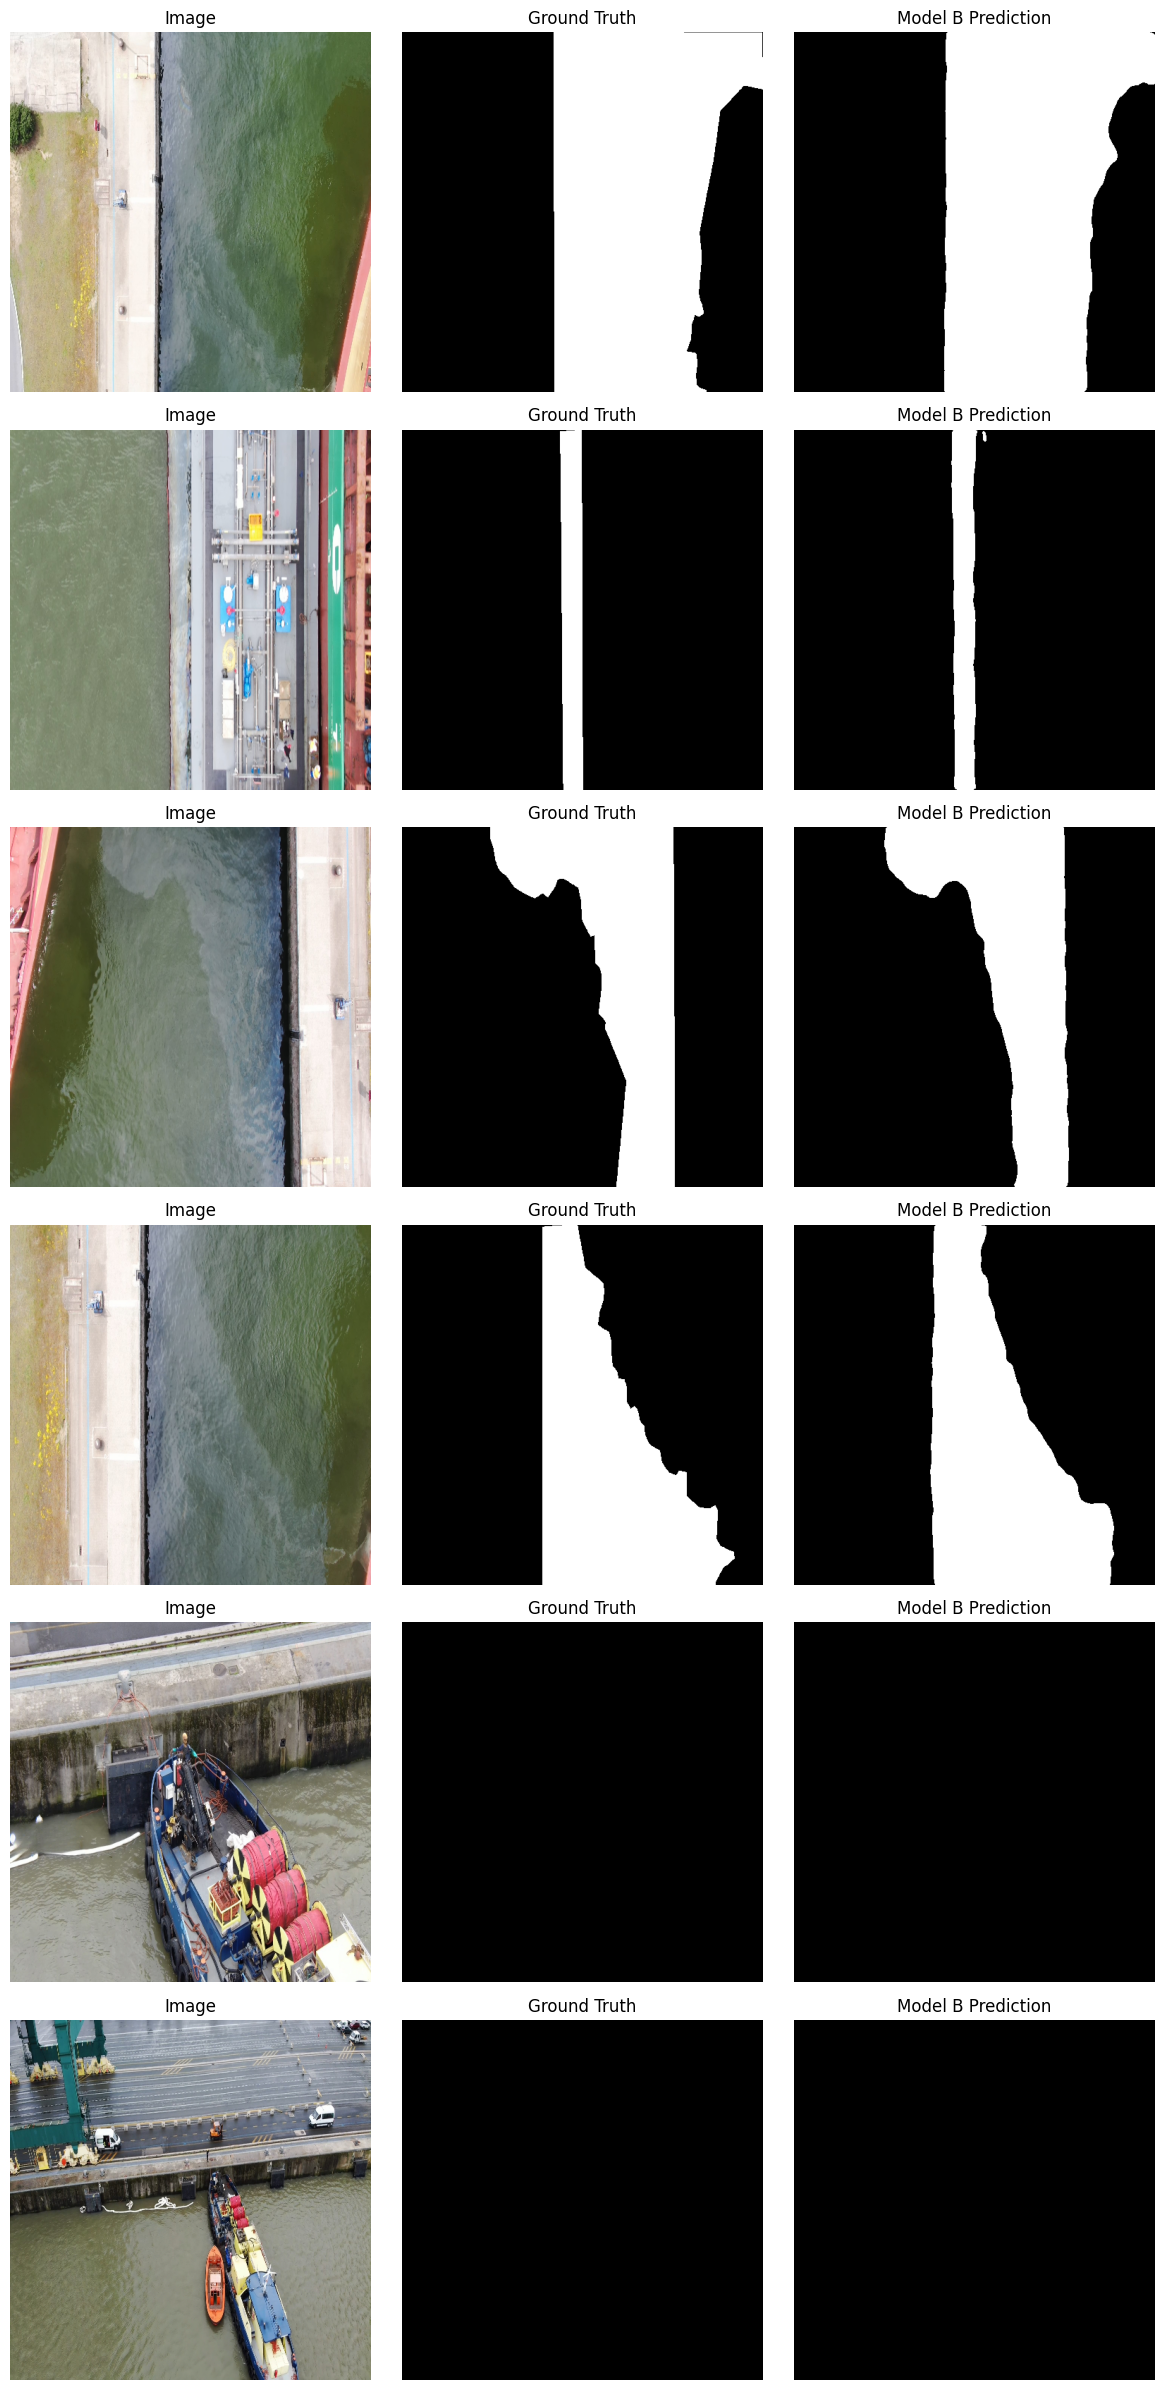

In [ ]:
@torch.no_grad()
def visualize_predictions(model, dataset, device, n=6, threshold=0.5, save_path=None):
    model.eval()
    indices = random.sample(range(len(dataset)), min(n, len(dataset)))
    fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n))
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    for row, idx in enumerate(indices):
        image, mask = dataset[idx]
        logits = model(image.unsqueeze(0).to(device))
        pred = (torch.sigmoid(logits) > threshold).float().cpu()[0, 0]
        img_vis = (image * std + mean).permute(1, 2, 0).clamp(0, 1).numpy()
        axes[row, 0].imshow(img_vis); axes[row, 0].set_title("Image"); axes[row, 0].axis("off")
        axes[row, 1].imshow(mask[0].numpy(), cmap="gray"); axes[row, 1].set_title("Ground Truth"); axes[row, 1].axis("off")
        axes[row, 2].imshow(pred.numpy(), cmap="gray"); axes[row, 2].set_title("Model B Prediction"); axes[row, 2].axis("off")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
        print(f"Saved to {save_path}")
    plt.show()

visualize_predictions(model_b, test_dataset, DEVICE, n=6,
                       save_path=os.path.join(PLOTS_DIR, "model_b_predictions.png"))


## 10. Training Curves

Saved to /content/drive/MyDrive/oil_spill_project_outputs/plots/model_b_training_curves.png


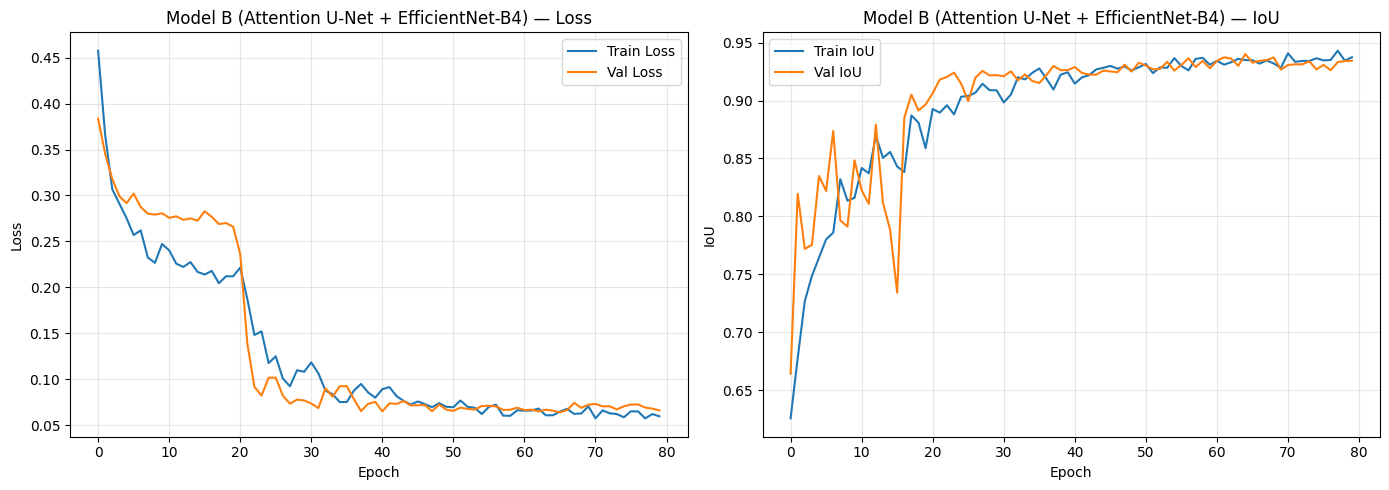

In [ ]:
def plot_training_curves(history, model_name, save_path=None):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(history["train_loss"], label="Train Loss")
    axes[0].plot(history["val_loss"], label="Val Loss")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].set_title(f"{model_name} — Loss")
    axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].plot(history["train_iou"], label="Train IoU")
    axes[1].plot(history["val_iou"], label="Val IoU")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("IoU"); axes[1].set_title(f"{model_name} — IoU")
    axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
        print(f"Saved to {save_path}")
    plt.show()

plot_training_curves(history_b, "Model B (Attention U-Net + EfficientNet-B4)",
                      save_path=os.path.join(PLOTS_DIR, "model_b_training_curves.png"))


## 11. Attention Map Visualization (Preview)

A quick look at the raw attention coefficients before the full Grad-CAM treatment in Notebook 4 — useful here as a sanity check that the gates have learned something non-trivial (not collapsed to uniform 0.5 everywhere).

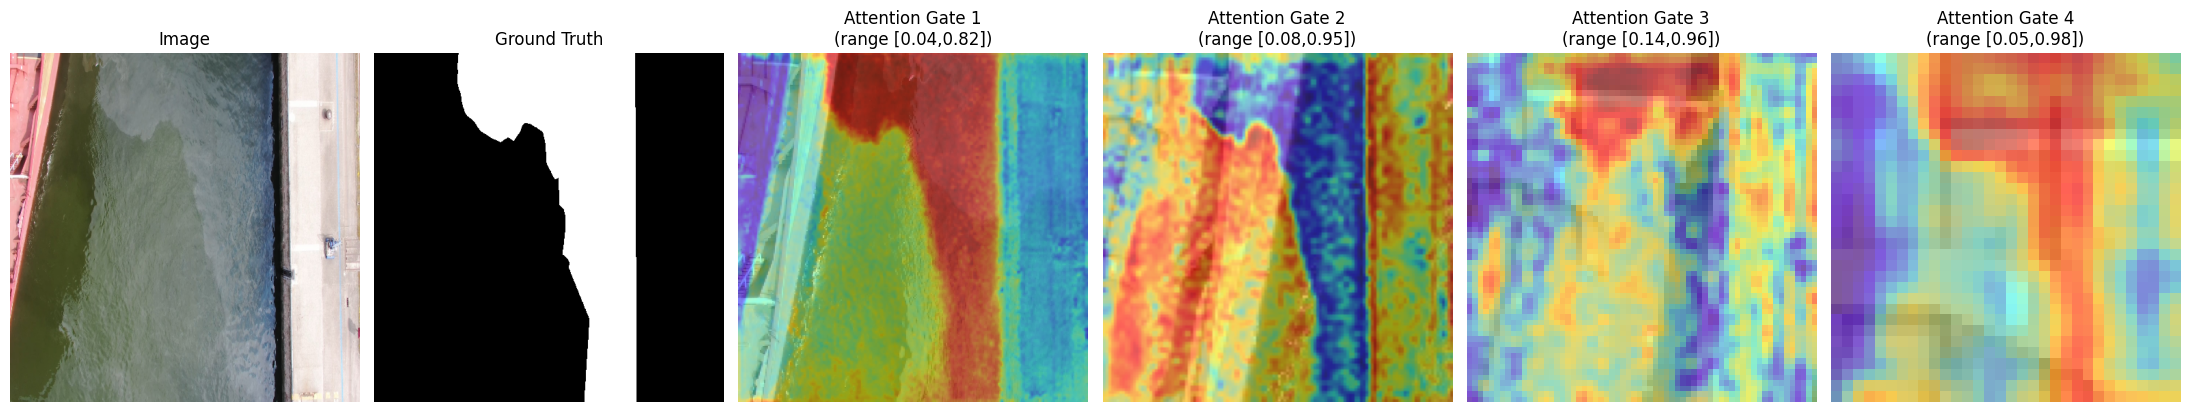

In [ ]:
@torch.no_grad()
def preview_attention_maps(model, dataset, device, idx=None):
    model.eval()
    if idx is None:
        idx = random.randint(0, len(dataset) - 1)
    image, mask = dataset[idx]
    logits, attn_maps = model(image.unsqueeze(0).to(device), return_attention_maps=True)

    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    img_vis = (image * std + mean).permute(1, 2, 0).clamp(0, 1).numpy()

    fig, axes = plt.subplots(1, 6, figsize=(22, 4))
    axes[0].imshow(img_vis); axes[0].set_title("Image"); axes[0].axis("off")
    axes[1].imshow(mask[0].numpy(), cmap="gray"); axes[1].set_title("Ground Truth"); axes[1].axis("off")
    for i, attn in enumerate(attn_maps, start=1):
        attn_np = attn[0, 0].cpu().numpy()
        axes[i + 1].imshow(img_vis)
        axes[i + 1].imshow(attn_np, cmap="jet", alpha=0.5)
        axes[i + 1].set_title(f"Attention Gate {i}\n(range [{attn_np.min():.2f},{attn_np.max():.2f}])")
        axes[i + 1].axis("off")
    plt.tight_layout()
    plt.show()

preview_attention_maps(model_b, test_dataset, DEVICE)


## Summary

Model B — an Attention U-Net with EfficientNet-B4 encoder, four manually-implemented
attention gates (one per skip connection), trained with Dice + Focal loss — isolates the
contribution of the attention mechanism over Model A's plain U-Net baseline. Checkpoint,
history, test metrics, and visualizations are saved to Google Drive.

**Next:** Notebook 4 implements **Model C** — the proposed model, replacing the loss with a
hybrid **Boundary IoU Loss + Focal Loss** (Boundary IoU implemented entirely from scratch),
plus the Grad-CAM explainability pipeline applied to these same attention gates.
